# Orion Finance Manager & LP analytics walkthrough

Walkthrough for **managers** and **LPs** on Orion.

**Audience**

- **Managers**: discover vaults, inspect names/fees/intent, understand expected rebalancing
- **LPs**: compare share-price paths, correlations, and **SASR** rankings across the product suite

Docs: https://sdk.orionfinance.ai/


## 0. Install

In the environment where you run this notebook:

```bash
uv pip install orion-finance-sdk-py matplotlib
```

Optional: set `RPC_URL` in a `.env` (Alchemy/Infura recommended for multi-vault history).
If unset, the SDK probes public Sepolia RPCs (fine for discovery; slow for long series).


In [1]:
from __future__ import annotations

import os
from datetime import datetime, timedelta, timezone

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from orion_finance_sdk_py import (
    OrionConfig,
    OrionEncryptedVault,
    OrionTransparentVault,
    ReturnSeries,
    covariance,
    measures,
    rank_products,
)
from orion_finance_sdk_py.stats import (
    expanding_sasr,
    normalized_prices,
    ranking_metrics,
    rfr_decimal,
)

load_dotenv()

LOOKBACK_DAYS = int(os.getenv("ORION_ANALYTICS_LOOKBACK_DAYS", "90"))
MAX_VAULTS = int(os.getenv("ORION_ANALYTICS_MAX_VAULTS", "0"))  # 0 = all

print(f"Lookback: {LOOKBACK_DAYS} days")
print(f"RPC_URL:  {'set' if os.getenv('RPC_URL') else 'unset (SDK public RPC cascade)'}")

Lookback: 90 days
RPC_URL:  set


## 1. Protocol snapshot

Connect via `OrionConfig` and print a few protocol-level facts before touching vaults.


In [2]:
config = OrionConfig()
rfr = rfr_decimal(config.risk_free_rate)

print(f"Chain ID:           {config.chain_id}")
print(f"Underlying asset:   {config.underlying_asset}")
print(f"System idle:        {config.is_system_idle()}")
print(f"Risk-free rate:     {config.risk_free_rate} bps  ({rfr:.2%})")
print(f"Whitelisted assets: {len(config.whitelisted_assets)}")
print(f"Transparent vaults: {len(config.orion_transparent_vaults)}")
print(f"Encrypted vaults:   {len(config.orion_encrypted_vaults)}")

# Map token address -> human name for nicer charts later
asset_names = dict(
    zip(config.whitelisted_assets, config.whitelisted_asset_names, strict=False)
)


def label_asset(addr: str) -> str:
    """Prefer whitelist name; fall back to a short address."""
    name = asset_names.get(addr) or asset_names.get(addr.lower())
    if name:
        return name
    return f"{addr[:6]}…{addr[-4:]}"


Chain ID:           11155111
Underlying asset:   0x1c7D4B196Cb0C7B01d743Fbc6116a902379C7238
System idle:        False
Risk-free rate:     410 bps  (4.10%)
Whitelisted assets: 112
Transparent vaults: 11
Encrypted vaults:   1


## 2. Discover active vaults

List registered **transparent** and **encrypted** vaults. Print the fields managers care about day-to-day: **name**, **symbol**, roles, share price, fee model.

Share price and TVL are public for both types. Encrypted vaults keep strategist intent and the live book as HPKE ciphertext — those are skipped in section 4.


In [3]:
transparent_addrs = list(config.orion_transparent_vaults)
encrypted_addrs = list(config.orion_encrypted_vaults)
if MAX_VAULTS > 0:
    transparent_addrs = transparent_addrs[:MAX_VAULTS]

specs: list[tuple[str, str]] = [("transparent", a) for a in transparent_addrs] + [
    ("encrypted", a) for a in encrypted_addrs
]

print(f"Transparent vaults: {len(transparent_addrs)}")
print(f"Encrypted vaults:   {len(encrypted_addrs)}")
if not specs:
    raise RuntimeError("No Orion vaults found on this chain/config.")

vaults: list[OrionTransparentVault | OrionEncryptedVault] = []
rows: list[dict] = []

for kind, addr in specs:
    vault = (
        OrionEncryptedVault(contract_address=addr)
        if kind == "encrypted"
        else OrionTransparentVault(contract_address=addr)
    )
    vaults.append(vault)
    fee = vault.active_fee_model
    row = {
        "kind": kind,
        "address": addr,
        "name": vault.name,
        "symbol": vault.symbol,
        "decimals": vault.decimals,
        "manager": vault.manager_address,
        "strategist": vault.strategist_address,
        "total_assets": vault.total_assets,
        "share_price": vault.share_price,
        "decommissioning": vault.is_decommissioning,
        "fee_type": fee["feeType"],
        "performance_fee_bps": fee["performanceFee"],
        "management_fee_bps": fee["managementFee"],
    }
    rows.append(row)

vault_table = pd.DataFrame(rows)
vault_table


Transparent vaults: 11
Encrypted vaults:   1


,kind,address,name,symbol,decimals,manager,strategist,total_assets,share_price,decommissioning,fee_type,performance_fee_bps,management_fee_bps
0,transparent,0x6121Eaa1D94A519653721904CEAb48eDD98f2c3a,KBestTvlWeightedAverage,KTWA,18,0xF97e66d9602de128FdFC8bcBe6651f1FC89c8AF2,0x6064cc0b31c0Ebf5D01490aA18A495116e6E494F,1028786070,996925,False,0,0,10
1,transparent,0x4a97ECfeE8F31618827C5E174233705427f739E2,HG-1 Fund,HFG,18,0x1788FF55308F4eb6285E2547F65fb0f252e20a03,0x1788FF55308F4eb6285E2547F65fb0f252e20a03,2381646522,1205699,False,0,200,20
2,transparent,0x5E0C164eE4Ec34Fa4Ac7Ca5c9E605f1558c97F4e,Sail Yield Agent,SAIL,18,0xF02a77EeF4B11f18cEb75111030a6e1B700b381c,0xF02a77EeF4B11f18cEb75111030a6e1B700b381c,1167011355,1051208,False,0,0,0
3,transparent,0xdB3039D992804186e971490A4DC54C082f93e70F,Bitcoin Ether 50-50,BE50,18,0xF97e66d9602de128FdFC8bcBe6651f1FC89c8AF2,0xF97e66d9602de128FdFC8bcBe6651f1FC89c8AF2,215892081,1377439,False,0,0,10
4,transparent,0xb0b4FccC8FFF133532c2c8e7bC01853ebEBe8f68,ABN AMRO Moderate,ABNA,18,0xA5c9eA6F8a71EDF9216c1b9467fAE9BBc43B7144,0xA5c9eA6F8a71EDF9216c1b9467fAE9BBc43B7144,50149331,1002986,False,0,0,0
5,transparent,0xa52426E3922db2bD9411cB05e6E2e874453064Ce,Chronos Momentum,CHM,18,0x51d90542A6918942534AF6640655C151945ECf9B,0x51d90542A6918942534AF6640655C151945ECf9B,49582730,1229136,False,0,0,0
6,transparent,0xba136460fbA61a8E447fCE18f6ae9a460795A726,ETH Regime,RETH,18,0x374d0cb85c3A9F83AC2E5f29F9C33B079ed69582,0x374d0cb85c3A9F83AC2E5f29F9C33B079ed69582,74703355,1024492,False,0,0,0
7,transparent,0xd562fC6DB4060d4aA061b55496cE991091916497,Bitcoin Ether Market Cap,BEMC,18,0xF97e66d9602de128FdFC8bcBe6651f1FC89c8AF2,0xF97e66d9602de128FdFC8bcBe6651f1FC89c8AF2,137067261,1370672,False,0,0,10
8,transparent,0x4d6813acd9418b6Be1899A108B1b51ec588e75aA,BTC Regime,RBTC,18,0x374d0cb85c3A9F83AC2E5f29F9C33B079ed69582,0x374d0cb85c3A9F83AC2E5f29F9C33B079ed69582,1016317185,1015321,False,0,0,0
9,transparent,0x00f7d8C1CA66D535C37264ad5A6293017cf5D22f,Owney USDC,USDO,18,0xf86803326f725eC21400dbcb9a15e41D01Ca6C7c,0xf86803326f725eC21400dbcb9a15e41D01Ca6C7c,664766608,1004318,False,0,0,0


## 3. Daily share-price panel + return correlation

For each active vault (transparent **and** encrypted), pull `share_price_history(..., interval="1d")`.
Vaults deployed inside the lookback window contribute a shorter series (pre-deployment blocks are skipped).
Build a `ReturnSeries` and plot the **correlation heatmap** from contiguous daily returns.


In [4]:
end = datetime.now(timezone.utc)
start = end - timedelta(days=LOOKBACK_DAYS)

active_vaults = [v for v in vaults if not v.is_decommissioning]
if not active_vaults:
    active_vaults = vaults  # fall back if everything is flagged

print(f"Sampling daily share prices from {start.date()} → {end.date()} …")

histories: dict[str, list[dict]] = {}
used: set[str] = set()
for vault in active_vaults:
    col = vault.symbol or vault.contract_address[:8]
    if col in used:
        col = f"{col}_{vault.contract_address[:6]}"
    used.add(col)
    history = vault.share_price_history(start=start, end=end, interval="1d")
    if not history:
        print(f"  skip {col}: empty history")
        continue
    histories[col] = history
    print(f"  {col}: {len(history)} points")

if not histories:
    raise RuntimeError("No share-price history for the selected vaults.")

rs = ReturnSeries.from_share_price_histories(histories)
prices = rs.prices
corr = (
    covariance.correlation(rs)
    if prices is not None and prices.shape[1] >= 2
    else pd.DataFrame()
)
prices


Sampling daily share prices from 2026-05-26 → 2026-08-24 …
  KTWA: 91 points
  HFG: 63 points
  SAIL: 91 points
  BE50: 63 points
  ABNA: 91 points
  CHM: 67 points
  RETH: 68 points
  BEMC: 56 points
  RBTC: 40 points
  USDO: 35 points
  ETHO: 35 points
  KS: 13 points


,KTWA,HFG,SAIL,BE50,ABNA,CHM,RETH,BEMC,RBTC,USDO,ETHO,KS
timestamp,,,,,,,,,,,,
2026-05-26 17:03:48+00:00,996847.0,NaN,1000831.0,NaN,1004403.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-27 17:03:48+00:00,997061.0,NaN,1001092.0,NaN,1004702.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-28 17:03:48+00:00,997261.0,NaN,1001237.0,NaN,1004875.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-29 17:03:48+00:00,997470.0,NaN,1001338.0,NaN,1005046.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-30 17:03:48+00:00,997678.0,NaN,1001433.0,NaN,1005215.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-08-20 17:03:48+00:00,996610.0,1147969.0,1034811.0,1270895.0,1002608.0,1131878.0,1024066.0,1263035.0,1014899.0,1004286.0,1192966.0,1007888.0
2026-08-21 17:03:48+00:00,996882.0,1184355.0,1043685.0,1330504.0,1002707.0,1205900.0,1024176.0,1338169.0,1015008.0,1004318.0,1227090.0,1052783.0
2026-08-22 17:03:48+00:00,996924.0,1190607.0,1046338.0,1346280.0,1002801.0,1208433.0,1024276.0,1345040.0,1015107.0,1004318.0,1253402.0,1066066.0


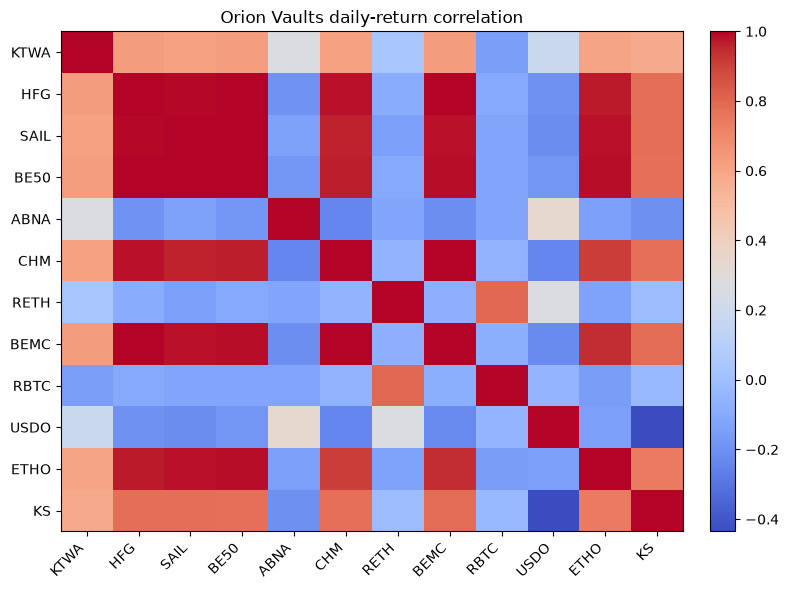

In [5]:
if corr.empty:
    print("Not enough overlapping returns for a correlation heatmap.")
else:
    fig, ax = plt.subplots(figsize=(8, 6))
    vmin = np.nanmin(corr.values)
    vmax = np.nanmax(corr.values)
    im = ax.imshow(corr.values, vmin=vmin, vmax=vmax, cmap="coolwarm", aspect="auto")
    ax.set_xticks(range(len(corr.columns)))
    ax.set_yticks(range(len(corr.index)))
    ax.set_xticklabels(corr.columns, rotation=45, ha="right")
    ax.set_yticklabels(corr.index)
    ax.set_title("Orion Vaults daily-return correlation")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    plt.show()


### Overlay normalized share-price paths

Rebase each series to 1.0 at the first observation so LPs can eyeball relative performance.


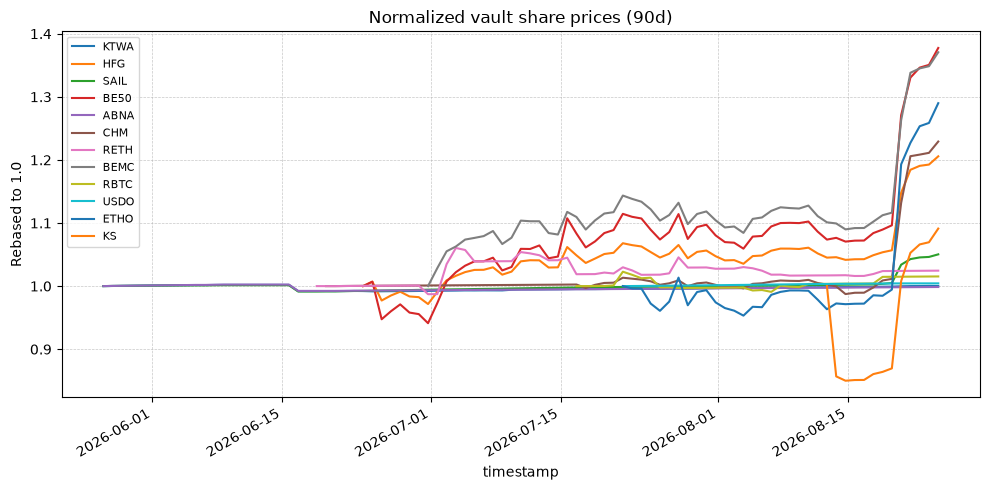

In [7]:
if prices is not None and not prices.empty:
    normalized = normalized_prices(prices)
    fig, ax = plt.subplots(figsize=(10, 5))
    normalized.plot(ax=ax)
    ax.set_title(f"Normalized vault share prices ({LOOKBACK_DAYS}d)")
    ax.set_ylabel("Rebased to 1.0")
    ax.legend(loc="best", fontsize=8)
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
    fig.tight_layout()
    plt.show()


## 4. Intent vs PIT allocation (expected rebalancing)

On a **transparent** vault:

- `get_intent()` - strategist **target** weights for the next rebalance (fractions, sum ≈ 1)
- `get_portfolio_pct_tvl()` - **current** book estimated with PIT oracle prices

The gap is the **expected rebalancing**. Encrypted vaults return opaque ciphertext for both calls, so they cannot be compared here (they still enter the share-price panel and SASR ranking).


In [8]:
focus_vault = next(
    (v for v in active_vaults if isinstance(v, OrionTransparentVault)),
    None,
)

if focus_vault is None:
    print(
        "No transparent vault in the sample — skip intent vs PIT "
        "(encrypted intent/portfolio are HPKE ciphertext)."
    )
    compare = pd.DataFrame()
else:
    intent = focus_vault.get_intent()
    current = focus_vault.get_portfolio_pct_tvl()

    all_tokens = sorted(set(intent) | set(current), key=lambda a: label_asset(a))
    compare = pd.DataFrame(
        {
            "intent": [intent.get(t, 0.0) for t in all_tokens],
            "current": [current.get(t, 0.0) for t in all_tokens],
        },
        index=[label_asset(t) for t in all_tokens],
    )
    compare["delta"] = compare["intent"] - compare["current"]
    compare = compare.map(lambda x: float(f"{x:.4f}"))

compare


,intent,current,delta
DAI-1 yVault,0.0042,0.0042,-0.0
DAI-2 yVault,0.0002,0.0002,0.0
EVK Vault eRLUSD-7,0.0339,0.0339,-0.0
EVK Vault eUSDe-6,0.0002,0.0002,0.0
Savings Dai,0.0938,0.0938,-0.0
Staked FRAX,0.0366,0.0366,-0.0
Staked USDe,0.7687,0.7687,-0.0
Steakhouse ETH,0.0000,0.0000,0.0
Steakhouse Prime EURCV,0.0623,0.0623,-0.0
USDC,0.0000,0.0000,-0.0


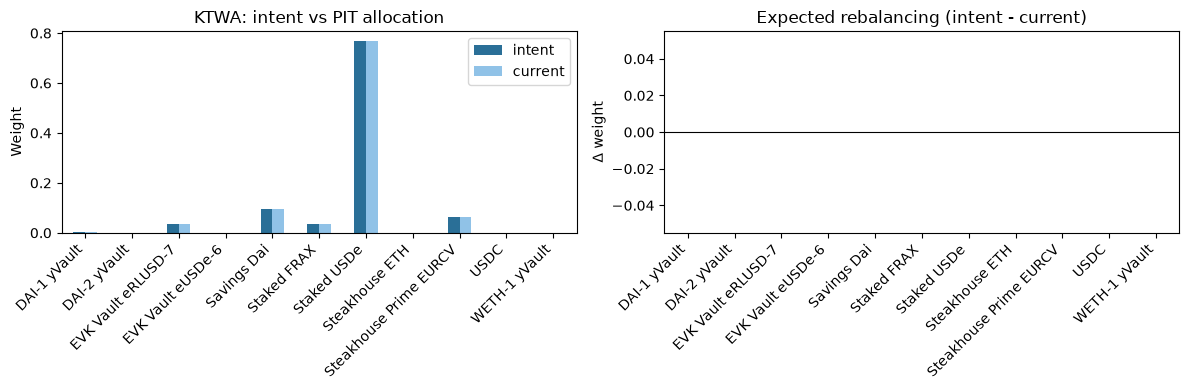

In [9]:
if compare.empty or focus_vault is None:
    print("Skip intent vs PIT plot.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

    compare[["intent", "current"]].plot(
        kind="bar", ax=axes[0], color=["#2a6f97", "#90c2e7"]
    )
    axes[0].set_title(f"{focus_vault.symbol}: intent vs PIT allocation")
    axes[0].set_ylabel("Weight")
    axes[0].tick_params(axis="x", rotation=45)
    axes[0].legend(loc="best")
    fig.autofmt_xdate(rotation=45, ha="right")

    compare["delta"].plot(kind="bar", ax=axes[1], color="#ee6c4d")
    axes[1].axhline(0, color="black", linewidth=0.8)
    axes[1].set_title("Expected rebalancing (intent - current)")
    axes[1].set_ylabel("Δ weight")
    axes[1].tick_params(axis="x", rotation=45)
    fig.autofmt_xdate(rotation=45, ha="right")

    fig.tight_layout()
    plt.show()


## 5. LP view: product ranking (SASR)

`product_scoreboard` joins path stats with Orion ranking fields and sorts by **SASR** descending — the only product ranking score. Do not rank by window total return or raw Sharpe.


In [10]:
scoreboard = measures.product_scoreboard(rs, rfr=rfr)
ranking = rank_products(rs, rfr=rfr)
scoreboard


,n_obs,mean,vol,sharpe,sortino,cvar,var,max_drawdown,total_return,cagr,total_excess,sample_sharpe,dasr,sasr,t_eff,t_weeks,w,vsr,rho
asset,,,,,,,,,,,,,,,,,,,
BEMC,55,0.005990,0.434112,4.943773,10.384345,0.022666,0.017947,0.051755,0.370672,7.104771,0.364599,4.943773,7.375683,1.473882,36.369042,5.195577,0.199830,0.449275,0.256138
CHM,66,0.003264,0.324672,3.545965,13.818540,0.008618,0.005499,0.025571,0.229136,2.129787,0.221844,3.545965,6.964770,1.389053,36.298059,5.185437,0.199440,0.259212,0.409140
BE50,62,0.005517,0.514755,3.834005,7.268360,0.038197,0.020279,0.065331,0.377439,5.587681,0.370590,3.834005,4.978817,1.340287,48.994015,6.999145,0.269198,0.592998,0.132730
HFG,62,0.003128,0.284559,3.870549,7.316267,0.020309,0.011485,0.035206,0.205699,2.007885,0.198850,3.870549,5.004715,1.309143,47.607910,6.801130,0.261582,0.598117,0.151152
SAIL,90,0.000551,0.064425,2.499921,7.140872,0.002213,-0.000000,0.009959,0.050335,0.220384,0.040378,2.499921,4.026571,1.266662,57.252800,8.178971,0.314576,0.385462,0.285988
ETHO,34,0.008135,0.716055,4.090586,10.231590,0.035268,0.023898,0.059430,0.289947,14.382308,0.286197,4.090586,6.636019,1.029076,28.223535,4.031934,0.155074,0.379976,0.102334
USDO,34,0.000127,0.001233,4.927660,6.044297,-0.000000,-0.000000,-0.000000,0.004318,0.047342,0.000568,4.927660,4.411615,0.461460,19.037392,2.719627,0.104601,1.247632,0.392979
RBTC,39,0.000403,0.098845,1.081294,1.850354,0.010357,0.005370,0.031257,0.015321,0.152924,0.011018,1.081294,1.123044,0.329394,53.381443,7.625920,0.293305,0.927030,-0.134705
RETH,67,0.000401,0.173532,0.612520,1.108355,0.018650,0.013723,0.041875,0.024492,0.140902,0.017089,0.612520,0.634761,0.184004,52.757983,7.536855,0.289879,0.931150,0.134975


## 6. Ranking metric over time

`expanding_sasr` recomputes SASR at each date from all contiguous daily returns **up to that date**. Early values are smaller because the track-record weight `w` ramps with Lo effective sample size. The last row matches `rank_products`.


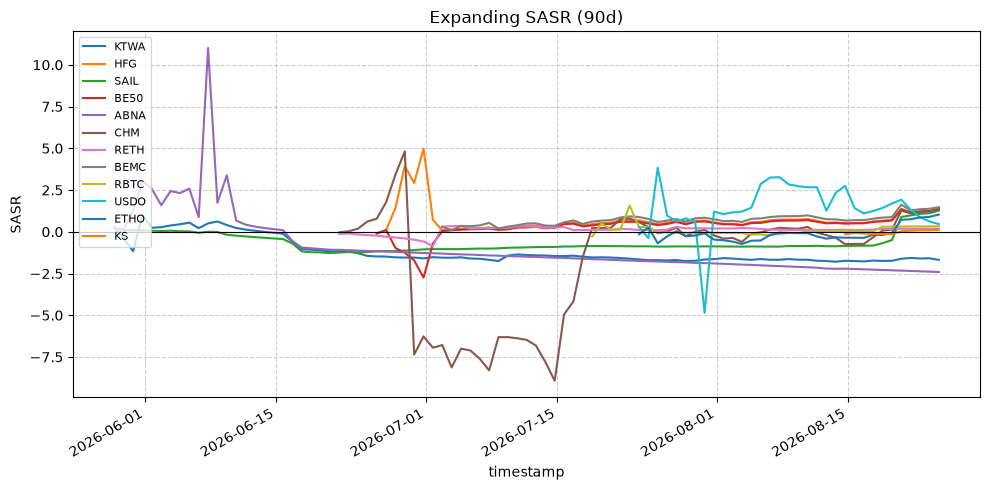

,KTWA,HFG,SAIL,BE50,ABNA,CHM,RETH,BEMC,RBTC,USDO,ETHO,KS
timestamp,,,,,,,,,,,,
2026-08-20 17:03:48+00:00,-1.614397,1.379356,0.888224,1.328065,-2.327213,1.262805,0.178576,1.624601,0.312554,1.924083,0.715681,0.025080
2026-08-21 17:03:48+00:00,-1.570373,1.142005,0.979982,1.163112,-2.345796,1.099810,0.179984,1.280022,0.316966,1.320573,0.751244,0.065556
2026-08-22 17:03:48+00:00,-1.599300,1.192001,1.074631,1.218079,-2.366731,1.199157,0.181286,1.347813,0.321021,0.868874,0.854311,0.083352
2026-08-23 17:03:48+00:00,-1.589071,1.216164,1.108677,1.244161,-2.388686,1.233847,0.182641,1.376265,0.325208,0.617184,0.892301,0.091691
2026-08-24 17:03:48+00:00,-1.682591,1.309143,1.266662,1.340287,-2.410234,1.389053,0.184004,1.473882,0.329394,0.461460,1.029076,0.116684


In [18]:
sasr_path = expanding_sasr(rs, rfr)
if sasr_path.dropna(how="all").empty:
    print("Not enough history for an expanding SASR path.")
else:
    fig, ax = plt.subplots(figsize=(10, 5))
    sasr_path.plot(ax=ax)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(f"Expanding SASR ({LOOKBACK_DAYS}d)")
    ax.set_ylabel("SASR")
    ax.legend(loc="best", fontsize=8)
    ax.grid(True, linestyle="--", alpha=0.6)
    fig.tight_layout()
    plt.show()
sasr_path.tail()


In [21]:
latest = ranking_metrics(rs, rfr)
compare_rank = pd.DataFrame(
    {
        "sasr": {name: m.sasr for name, m in latest.items()},
        "dasr": {name: m.dasr for name, m in latest.items()},
        "w": {name: m.w for name, m in latest.items()},
        "t_eff": {name: m.t_eff for name, m in latest.items()},
    }
).sort_values("sasr", ascending=False)
print("Latest cross-section (same order as rank_products):")
print(rank_products(rs, rfr))
compare_rank

Latest cross-section (same order as rank_products):
BEMC    1.473882
CHM     1.389053
BE50    1.340287
HFG     1.309143
SAIL    1.266662
ETHO    1.029076
USDO    0.461460
RBTC    0.329394
RETH    0.184004
KS      0.116684
KTWA   -1.682591
ABNA   -2.410234
Name: sasr, dtype: float64


,sasr,dasr,w,t_eff
BEMC,1.473882,7.375683,0.199830,36.369042
CHM,1.389053,6.964770,0.199440,36.298059
BE50,1.340287,4.978817,0.269198,48.994015
HFG,1.309143,5.004715,0.261582,47.607910
SAIL,1.266662,4.026571,0.314576,57.252800
ETHO,1.029076,6.636019,0.155074,28.223535
USDO,0.461460,4.411615,0.104601,19.037392
RBTC,0.329394,1.123044,0.293305,53.381443
RETH,0.184004,0.634761,0.289879,52.757983
KS,0.116684,2.628880,0.044385,8.078136
